# Visualiser l'évolution d'un classement ? Oublie les barres.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()

## Données

In [2]:
categories = ['A', 'B', 'C', 'D', 'E']
time_periods = [2020, 2021, 2022, 2023]

data = np.array([[1, 1, 2, 1],
                 [1, 1, 2, 5],
                 [5, 3, 2, 3],
                 [2, 4, 2, 4],
                 [4, 1, 5, 5]])

In [3]:
# Calculer le rang pour chaque catégorie au fil du temps
ranks = np.argsort(data, axis=0)[::-1]
rank_data = np.zeros_like(data)
for i in range(len(time_periods)):
    rank_data[:, i] = ranks[:, i] + 1
    
rank_data

array([[3, 4, 5, 5],
       [5, 3, 4, 2],
       [4, 5, 3, 4],
       [2, 2, 2, 3],
       [1, 1, 1, 1]])

## Graphique en barres (bar chart)

In [4]:
df = pd.DataFrame(6-rank_data.T,
                  columns=[str(i) for i in categories])
df["Time"] = time_periods

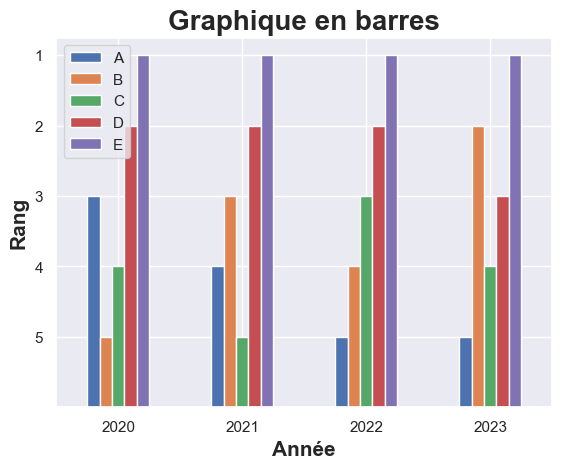

In [5]:
fig, ax = plt.subplots()

fig = df.plot(x='Time', kind='bar', stacked=False, ax=ax)

ax.set_xlabel('Année', fontsize=15, fontweight="bold")
ax.set_ylabel('Rang', fontsize=15, fontweight="bold")
ax.set_title('Graphique en barres', fontsize=20, fontweight="bold")

ax.set_xticklabels(df.Time, rotation=0)

ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.set_yticklabels(["", 5, 4, 3, 2, 1])

plt.show()

## Graphique d’évolution du classement (bump chart)

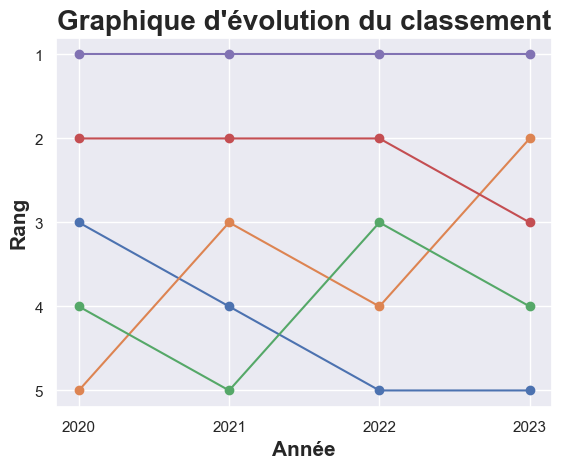

In [6]:
# Tracer le graphique d’évolution du classement (bump chart)
fig, ax = plt.subplots()
for i, cat in enumerate(categories):
    ax.plot(time_periods, rank_data[i], label=cat, marker="o")
    
ax.invert_yaxis()
ax.set_xlabel('Année', fontsize=15, fontweight="bold")
ax.set_ylabel('Rang', fontsize=15, fontweight="bold")
ax.set_title("Graphique d'évolution du classement", fontsize=20, fontweight="bold")

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.show()